In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

In [2]:
PROJECT_DIR = Path.cwd().parent

DATA = PROJECT_DIR/"processed"/"cleaned_dataset.csv"

df = pd.read_csv(DATA)

print(df.shape)

df.head()

(23424, 48)


,Week,Measurement_Site,Latitude,Longitude,Source_File,Vehicle_Category,Time,von Unten nach Oben,von Links nach Oben,von Links nach Unten,von Oben nach Unten,Fahrtrichtung Süd-West,Fahrtrichtung Nord-Ost,Fahrtrichtung Nord-West,Fahrtrichtung Süd-Ost,Fahrtrichtung Nord-Ost.1,Fahrtrichtung Süd-West.1,von Rechts nach Unten,von Rechts nach Oben,Von Links nach Oben,Von Links nach Unten,Von Oben nach Unten,Fahrtrichtung Süd,Fahrtrichtung Nord,Fahrtrichtung West,Fahrtrichtung Ost,Leicht-rechts in Links,Rechts in Oben,Geradeaus in Links,Rechts in Oben.1,Falschfahrer,Falschfahrer.1,Falschfahrer.2,Geradeaus in Unten,Geradeaus in Oben,Fahrtrichtung Nord.1,Fahrtrichtung Süd.1,von Rechts Links nach Unten,von Links Geradeaus in Rechts,von Oben Links in Rechts,von Oben Geradeaus in Unten,von Unten Geradeaus in Oben,nach Unten,Total_Traffic,Hour,Minute,Peak_Period,Time_Interval
0,DZwEI 08.10-13.10,Glauburgstraße,50.127065,8.689309,2024-10-08_to_2024-10-13_UI_202403B0923.xlsx,Bus,1900-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,Off Peak,00:00
1,DZwEI 08.10-13.10,Glauburgstraße,50.127065,8.689309,2024-10-08_to_2024-10-13_UI_202403B0923.xlsx,Bus,1900-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,15,Off Peak,00:15
2,DZwEI 08.10-13.10,Glauburgstraße,50.127065,8.689309,2024-10-08_to_2024-10-13_UI_202403B0923.xlsx,Bus,1900-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,30,Off Peak,00:30
3,DZwEI 08.10-13.10,Glauburgstraße,50.127065,8.689309,2024-10-08_to_2024-10-13_UI_202403B0923.xlsx,Bus,1900-01-01 00:45:00,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0,45,Off Peak,00:45
4,DZwEI 08.10-13.10,Glauburgstraße,50.127065,8.689309,2024-10-08_to_2024-10-13_UI_202403B0923.xlsx,Bus,1900-01-01 01:00:00,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,1,0,Off Peak,01:00


In [3]:
print("="*70)
print("Vehicle Categories")
print("="*70)

print(df["Vehicle_Category"].unique())

Vehicle Categories
<ArrowStringArray>
[             'Bus',       'Gesamt-Kfz',         'Kraftrad',
         'LV <3.5t',      'Lieferwagen',              'Lkw',
 'Lkw mit Anhänger',              'Pkw', 'Pkw mit Anhänger',
         'SV >3.5t',       'Sattel-Kfz']
Length: 11, dtype: str


In [4]:
analysis_df = df[
    df["Vehicle_Category"] != "Gesamt-Kfz"
].copy()

analysis_df.shape

(21120, 48)

In [5]:
hourly_profile = (

    analysis_df

    .groupby(
        ["Vehicle_Category","Hour"]
    )["Total_Traffic"]

    .mean()

    .reset_index()

)

hourly_profile = hourly_profile.sort_values(
    ["Vehicle_Category","Hour"]
)

hourly_profile.head()

,Vehicle_Category,Hour,Total_Traffic
0,Bus,0,1.083333
1,Bus,1,1.760417
2,Bus,2,1.583333
3,Bus,3,1.666667
4,Bus,4,1.656250


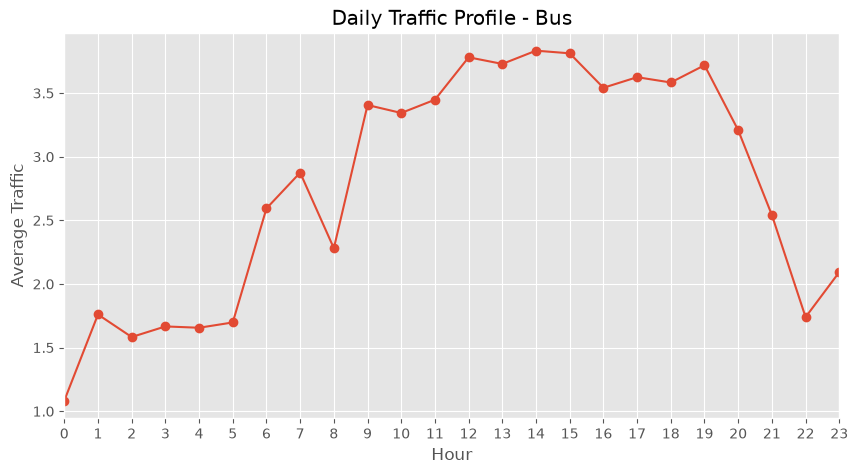

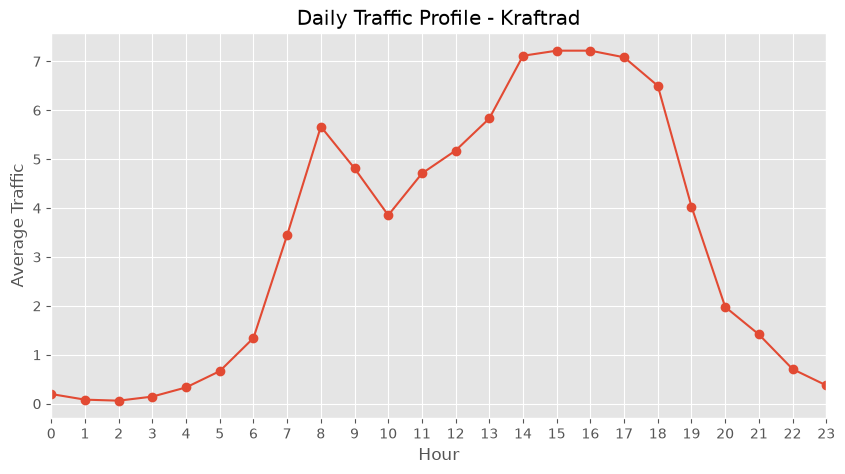

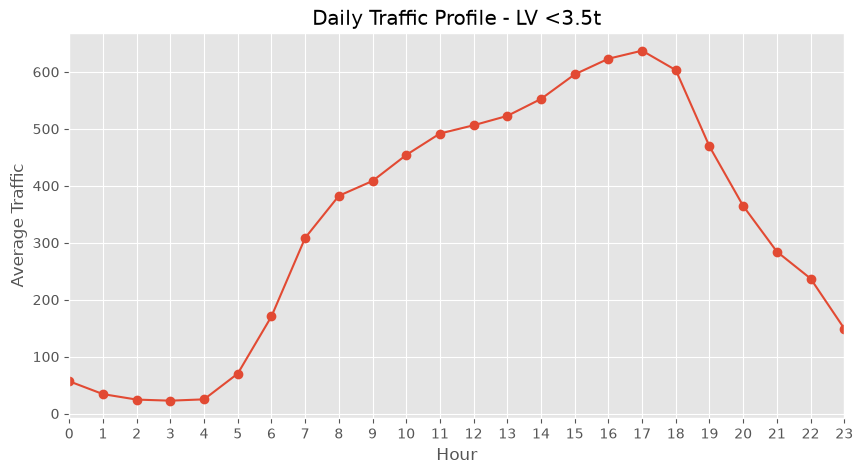

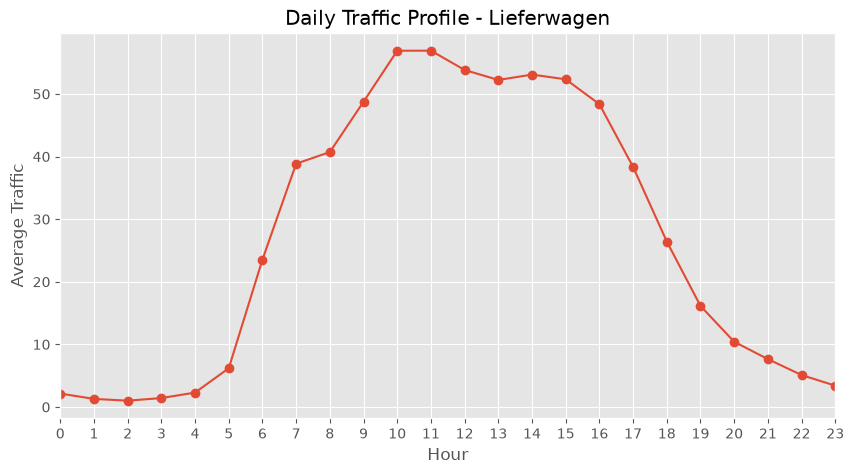

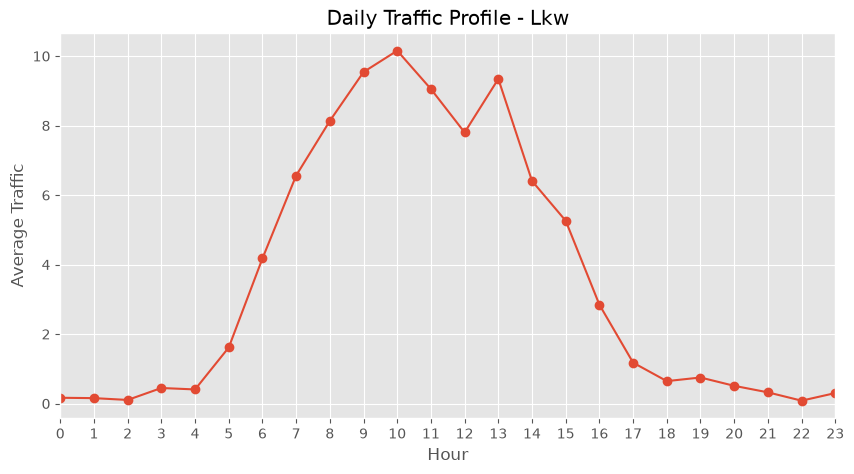

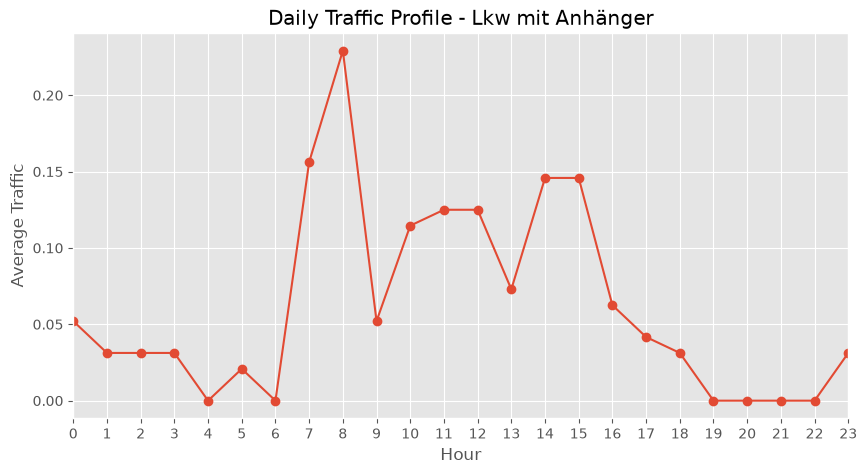

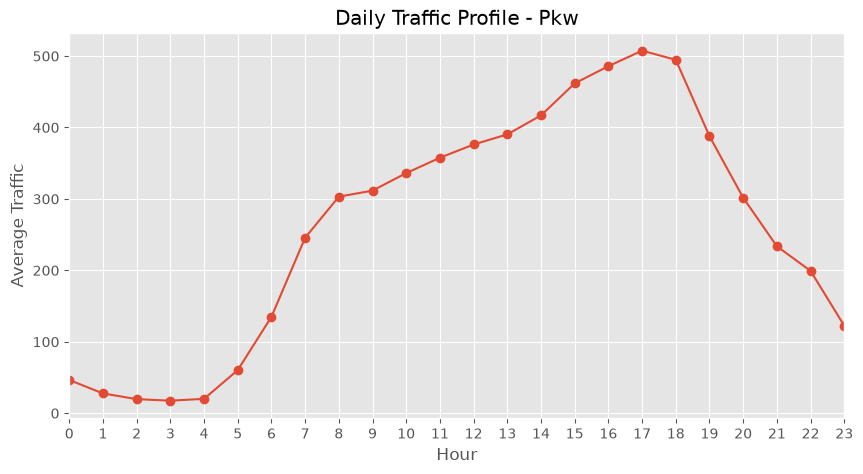

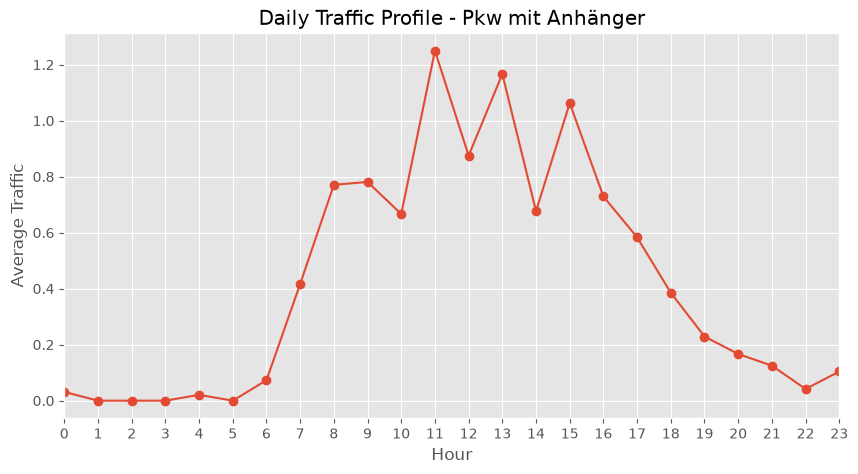

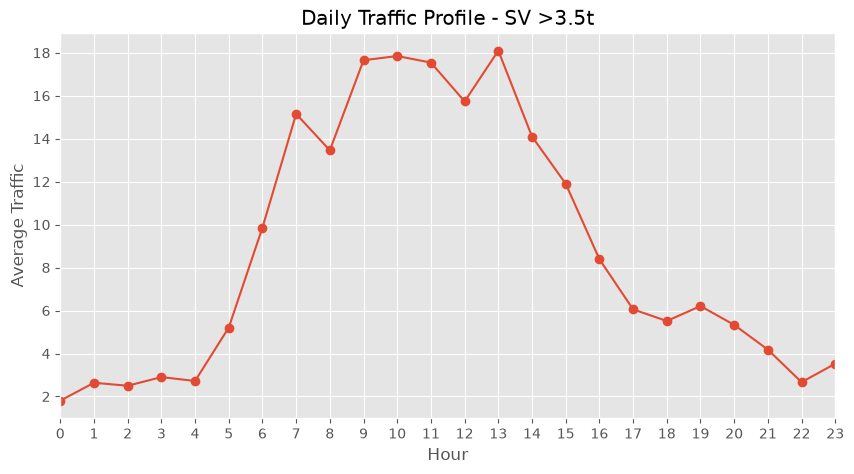

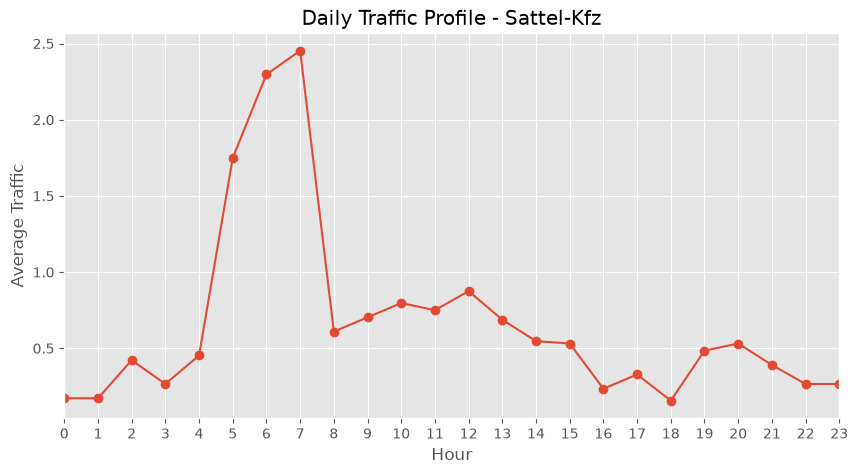

In [6]:
for vehicle in hourly_profile["Vehicle_Category"].unique():

    temp = hourly_profile[
        hourly_profile["Vehicle_Category"]==vehicle
    ]

    plt.figure(figsize=(10,5))

    plt.plot(
        temp["Hour"],
        temp["Total_Traffic"],
        marker="o"
    )

    plt.title(f"Daily Traffic Profile - {vehicle}")

    plt.xlabel("Hour")

    plt.ylabel("Average Traffic")

    plt.xticks(range(24))

    plt.xlim(0,23)

    plt.grid(True)

    plt.show()

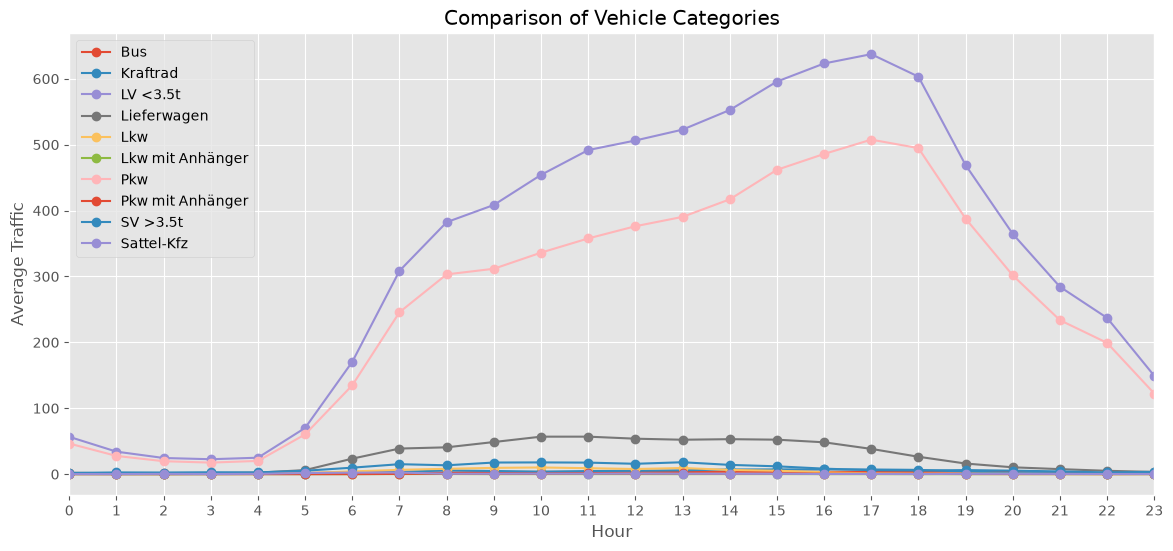

In [7]:
plt.figure(figsize=(14,6))

for vehicle in hourly_profile["Vehicle_Category"].unique():

    temp = hourly_profile[
        hourly_profile["Vehicle_Category"]==vehicle
    ]

    plt.plot(
        temp["Hour"],
        temp["Total_Traffic"],
        marker="o",
        label=vehicle
    )

plt.legend()

plt.xticks(range(24))

plt.xlim(0,23)

plt.xlabel("Hour")

plt.ylabel("Average Traffic")

plt.title("Comparison of Vehicle Categories")

plt.grid(True)

plt.show()

In [8]:
peak_hours = (

    hourly_profile

    .loc[
        hourly_profile
        .groupby("Vehicle_Category")
        ["Total_Traffic"]
        .idxmax()
    ]

)

peak_hours = peak_hours.sort_values(
    "Total_Traffic",
    ascending=False
)

peak_hours

,Vehicle_Category,Hour,Total_Traffic
65,LV <3.5t,17,637.277778
161,Pkw,17,507.562500
83,Lieferwagen,11,56.916667
205,SV >3.5t,13,18.097222
106,Lkw,10,10.156250
39,Kraftrad,15,7.218750
14,Bus,14,3.833333
223,Sattel-Kfz,7,2.453125
179,Pkw mit Anhänger,11,1.250000
128,Lkw mit Anhänger,8,0.229167


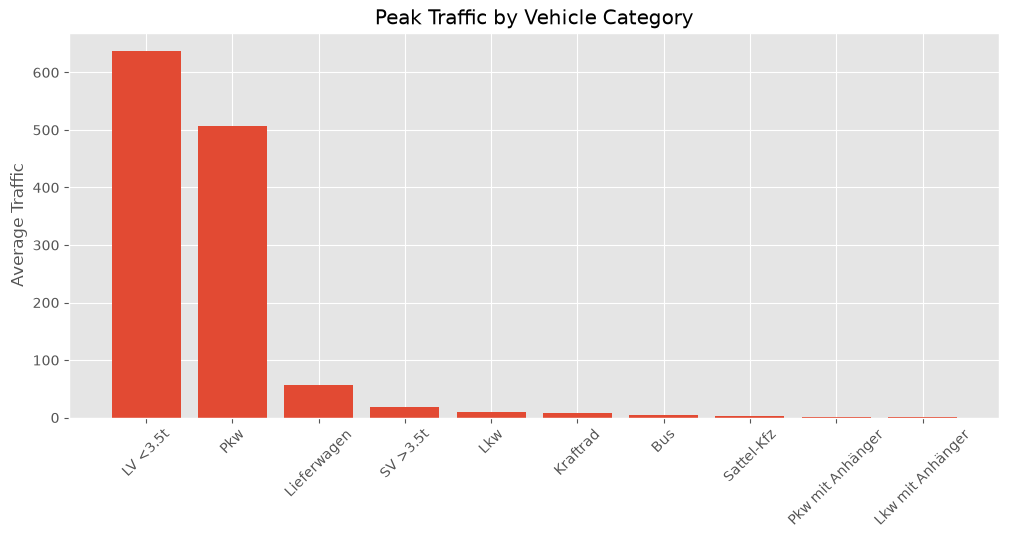

In [9]:
plt.figure(figsize=(12,5))

plt.bar(

    peak_hours["Vehicle_Category"],

    peak_hours["Total_Traffic"]

)

plt.xticks(rotation=45)

plt.ylabel("Average Traffic")

plt.title("Peak Traffic by Vehicle Category")

plt.show()

In [10]:
period = (

    analysis_df

    .groupby(
        ["Vehicle_Category","Peak_Period"]
    )["Total_Traffic"]

    .mean()

    .reset_index()

)

period.head()

,Vehicle_Category,Peak_Period,Total_Traffic
0,Bus,Evening Peak,3.640625
1,Bus,Midday,3.627083
2,Bus,Morning Peak,2.789062
3,Bus,Off Peak,2.068182
4,Kraftrad,Evening Peak,7.005208


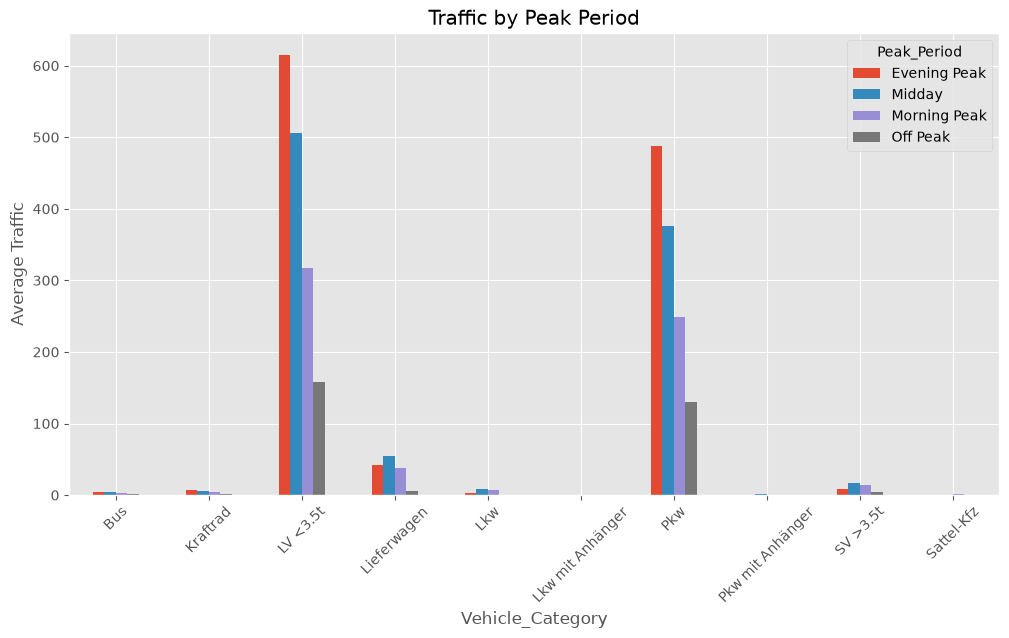

In [11]:
pivot = period.pivot(

    index="Vehicle_Category",

    columns="Peak_Period",

    values="Total_Traffic"

)

pivot.plot(

    kind="bar",

    figsize=(12,6)

)

plt.ylabel("Average Traffic")

plt.title("Traffic by Peak Period")

plt.xticks(rotation=45)

plt.show()

In [12]:
heatmap = pd.pivot_table(

    analysis_df,

    values="Total_Traffic",

    index="Vehicle_Category",

    columns="Hour",

    aggfunc="mean"

)

heatmap

Hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Vehicle_Category,,,,,,,,,,,,,,,,,,,,,,,,
Bus,1.083333,1.760417,1.583333,1.666667,1.656250,1.697917,2.593750,2.875000,2.281250,3.406250,3.343750,3.447917,3.781250,3.729167,3.833333,3.812500,3.541667,3.625000,3.583333,3.718750,3.208333,2.541667,1.739583,2.093750
Kraftrad,0.197917,0.083333,0.062500,0.145833,0.333333,0.666667,1.343750,3.447917,5.666667,4.812500,3.854167,4.708333,5.177083,5.833333,7.114583,7.218750,7.218750,7.083333,6.500000,4.031250,1.979167,1.416667,0.708333,0.375000
LV <3.5t,56.666667,34.166667,24.555556,22.666667,24.986111,70.194444,170.597222,308.513889,382.375000,408.472222,454.111111,491.777778,506.291667,522.750000,552.513889,595.680556,623.138889,637.277778,603.152778,469.027778,364.569444,284.305556,237.097222,149.166667
Lieferwagen,2.145833,1.291667,1.010417,1.427083,2.302083,6.187500,23.552083,38.864583,40.718750,48.760417,56.906250,56.916667,53.833333,52.239583,53.093750,52.343750,48.364583,38.343750,26.427083,16.135417,10.416667,7.645833,5.104167,3.406250
Lkw,0.166667,0.156250,0.104167,0.447917,0.406250,1.614583,4.177083,6.562500,8.135417,9.541667,10.156250,9.052083,7.802083,9.343750,6.406250,5.260417,2.843750,1.177083,0.645833,0.750000,0.510417,0.322917,0.083333,0.302083
Lkw mit Anhänger,0.052083,0.031250,0.031250,0.031250,0.000000,0.020833,0.000000,0.156250,0.229167,0.052083,0.114583,0.125000,0.125000,0.072917,0.145833,0.145833,0.062500,0.041667,0.031250,0.000000,0.000000,0.000000,0.000000,0.031250
Pkw,46.437500,27.677083,19.666667,17.541667,20.104167,60.364583,134.968750,245.739583,303.145833,311.656250,336.135417,357.666667,376.197917,390.385417,416.958333,461.802083,485.843750,507.562500,494.760417,387.770833,301.625000,233.666667,199.218750,122.385417
Pkw mit Anhänger,0.031250,0.000000,0.000000,0.000000,0.020833,0.000000,0.072917,0.416667,0.770833,0.781250,0.666667,1.250000,0.875000,1.166667,0.677083,1.062500,0.729167,0.583333,0.385417,0.229167,0.166667,0.125000,0.041667,0.104167
SV >3.5t,1.805556,2.638889,2.500000,2.902778,2.722222,5.208333,9.861111,15.152778,13.458333,17.652778,17.847222,17.541667,15.736111,18.097222,14.097222,11.902778,8.388889,6.055556,5.513889,6.208333,5.333333,4.180556,2.666667,3.527778


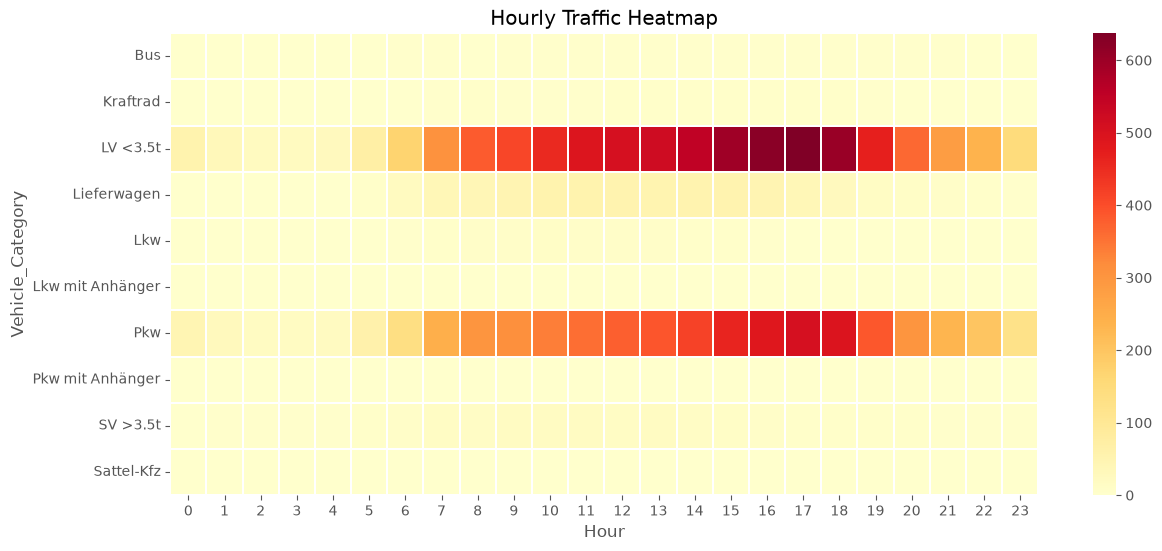

In [13]:
plt.figure(figsize=(14,6))

sns.heatmap(

    heatmap,

    cmap="YlOrRd",

    linewidths=0.3

)

plt.title("Hourly Traffic Heatmap")

plt.show()

In [14]:
vehicle_stats = (

    analysis_df

    .groupby("Vehicle_Category")

    ["Total_Traffic"]

    .agg(

        [

            "sum",

            "mean",

            "max",

            "min",

            "std"

        ]

    )

    .round(2)

)

vehicle_stats

,sum,mean,max,min,std
Vehicle_Category,,,,,
Bus,6394.0,2.78,30.0,0.0,4.42
Kraftrad,7678.0,3.33,57.0,0.0,6.14
LV <3.5t,575572.0,333.09,2274.0,0.0,446.12
Lieferwagen,62154.0,26.98,246.0,0.0,43.29
Lkw,8253.0,3.58,57.0,0.0,7.21
Lkw mit Anhänger,144.0,0.06,6.0,0.0,0.43
Pkw,600891.0,260.80,2082.0,0.0,373.47
Pkw mit Anhänger,975.0,0.42,18.0,0.0,1.30
SV >3.5t,15192.0,8.79,78.0,0.0,13.08


In [15]:
avg = (

    analysis_df

    .groupby("Vehicle_Category")

    ["Total_Traffic"]

    .mean()

    .sort_values(

        ascending=False

    )

)

avg

Vehicle_Category
LV <3.5t            333.085648
Pkw                 260.803385
Lieferwagen          26.976562
SV >3.5t              8.791667
Lkw                   3.582031
Kraftrad              3.332465
Bus                   2.775174
Sattel-Kfz            0.672526
Pkw mit Anhänger      0.423177
Lkw mit Anhänger      0.062500
Name: Total_Traffic, dtype: float64

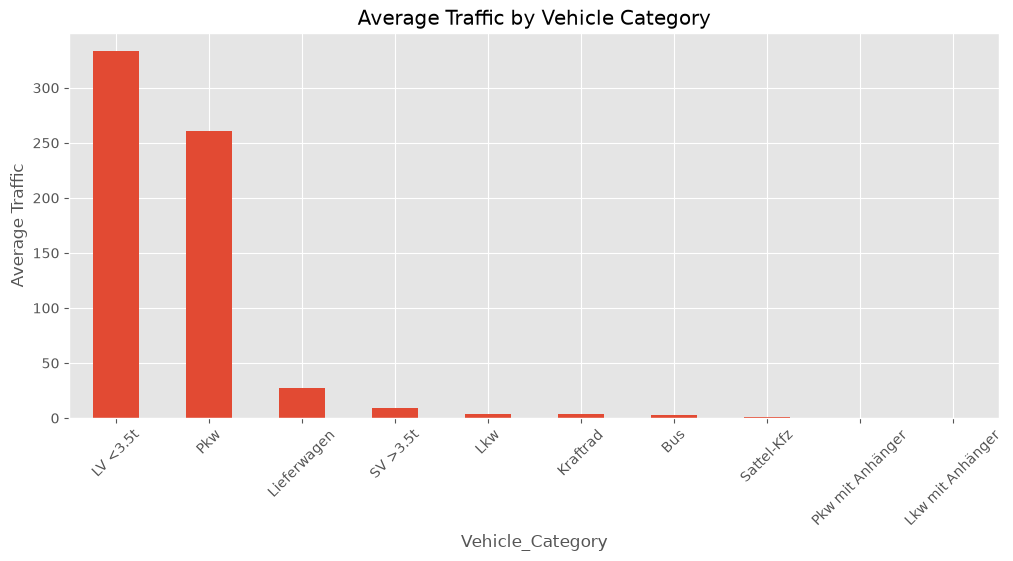

In [16]:
plt.figure(figsize=(12,5))

avg.plot(kind="bar")

plt.ylabel("Average Traffic")

plt.title("Average Traffic by Vehicle Category")

plt.xticks(rotation=45)

plt.show()

In [17]:
peak_summary = peak_hours.rename(

    columns={

        "Hour":"Peak Hour",

        "Total_Traffic":"Average Traffic"

    }

)

peak_summary

,Vehicle_Category,Peak Hour,Average Traffic
65,LV <3.5t,17,637.277778
161,Pkw,17,507.562500
83,Lieferwagen,11,56.916667
205,SV >3.5t,13,18.097222
106,Lkw,10,10.156250
39,Kraftrad,15,7.218750
14,Bus,14,3.833333
223,Sattel-Kfz,7,2.453125
179,Pkw mit Anhänger,11,1.250000
128,Lkw mit Anhänger,8,0.229167


In [18]:
print("="*70)

print("TASK 1 CONCLUSION")

print("="*70)

print()

print("• Passenger vehicles contribute the highest traffic volume.")

print("• Heavy vehicles (trucks, buses) show comparatively lower traffic.")

print("• Traffic follows a clear daily profile with distinct peak hours.")

print("• Morning and evening rush hours experience the highest traffic.")

print("• Peak hours for every vehicle category are listed above.")

TASK 1 CONCLUSION

• Passenger vehicles contribute the highest traffic volume.
• Heavy vehicles (trucks, buses) show comparatively lower traffic.
• Traffic follows a clear daily profile with distinct peak hours.
• Morning and evening rush hours experience the highest traffic.
• Peak hours for every vehicle category are listed above.


In [19]:
REPORT_DIR = PROJECT_DIR/"reports"

REPORT_DIR.mkdir(exist_ok=True)

vehicle_stats.to_csv(

    REPORT_DIR/"vehicle_statistics.csv"

)

peak_summary.to_csv(

    REPORT_DIR/"vehicle_peak_hours.csv",

    index=False

)

print("Notebook 5 Results Saved Successfully")

Notebook 5 Results Saved Successfully
